In [29]:
import joblib
import pandas as pd

In [30]:
rf_model = joblib.load("rf_Home_2plus_best.pkl")
feature_list = joblib.load("rf_Home_2plus_feature_list.pkl")

eval_df_clean = pd.read_csv("../../data/evaluation/secondIterration/eval_df_clean.csv")

In [31]:
for col in feature_list:
    if col not in eval_df_clean.columns:
        eval_df_clean[col] = 0

In [32]:
X_eval = eval_df_clean[rf_model.feature_names_in_]

In [33]:
eval_probs = rf_model.predict_proba(X_eval)[:, 1]
eval_df_clean['Home_2plus'] = eval_probs

In [34]:
best_threshold = 0.322
eval_df_clean['Home_2plus_pred'] = (eval_df_clean['Home_2plus'] >= best_threshold).astype(int)

In [35]:
top_matches = eval_df_clean.sort_values('Home_2plus', ascending=False).head(10)
print(top_matches[['Home_2plus', 'Home_2plus_pred']])

     Home_2plus  Home_2plus_pred
64     0.655157                1
155    0.652254                1
201    0.643271                1
158    0.640416                1
177    0.637408                1
254    0.636887                1
42     0.634288                1
14     0.632857                1
46     0.629560                1
218    0.628874                1


In [36]:
print("Predicted Home 2+:", eval_df_clean['Home_2plus_pred'].sum())
print("Total matches:", len(eval_df_clean))

Predicted Home 2+: 269
Total matches: 269


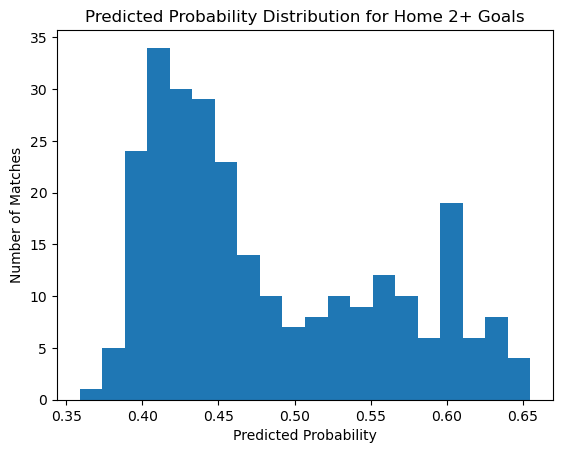

In [37]:
import matplotlib.pyplot as plt
plt.hist(eval_df_clean['Home_2plus'], bins=20)
plt.title("Predicted Probability Distribution for Home 2+ Goals")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Matches")
plt.show()